# Construction d'un GVAR global avec trois zones : USA, Europe et Japon

In [141]:
import pandas as pd
import numpy as np

## Analyse et Compréhension des bases de données TES

In [142]:
data_tes = pd.read_csv(
    "data/international_TES/2013_SML.csv",
    index_col=0,
    low_memory=False
)

data_tes.head()
print(data_tes.shape)

(3468, 3928)


In [143]:
print(data_tes.index[-10:])

Index(['ROW_N', 'ROW_O', 'ROW_P', 'ROW_Q', 'ROW_R', 'ROW_S', 'ROW_T', 'TLS',
       'VA', 'OUT'],
      dtype='str', name='V1')


In [144]:
print(data_tes.columns[-20:])

Index(['USA_DPABR', 'VNM_HFCE', 'VNM_NPISH', 'VNM_GGFC', 'VNM_GFCF',
       'VNM_INVNT', 'VNM_DPABR', 'ZAF_HFCE', 'ZAF_NPISH', 'ZAF_GGFC',
       'ZAF_GFCF', 'ZAF_INVNT', 'ZAF_DPABR', 'ROW_HFCE', 'ROW_NPISH',
       'ROW_GGFC', 'ROW_GFCF', 'ROW_INVNT', 'ROW_DPABR', 'OUT'],
      dtype='str')


In [145]:
cols = data_tes.columns

fd_start = [i for i, col in enumerate(cols) if "HFCE" in col][0]

print("FD commence à la colonne :", fd_start)
print("Nom de la colonne :", cols[fd_start])

FD commence à la colonne : 3465
Nom de la colonne : ARG_HFCE


In [146]:
FD_cols = data_tes.columns[fd_start:-1]  # -1 pour exclure OUT

print("Nombre colonnes FD :", len(FD_cols))
print(FD_cols[:10])
print(FD_cols[-10:])

Nombre colonnes FD : 462
Index(['ARG_HFCE', 'ARG_NPISH', 'ARG_GGFC', 'ARG_GFCF', 'ARG_INVNT',
       'ARG_DPABR', 'AUS_HFCE', 'AUS_NPISH', 'AUS_GGFC', 'AUS_GFCF'],
      dtype='str')
Index(['ZAF_GGFC', 'ZAF_GFCF', 'ZAF_INVNT', 'ZAF_DPABR', 'ROW_HFCE',
       'ROW_NPISH', 'ROW_GGFC', 'ROW_GFCF', 'ROW_INVNT', 'ROW_DPABR'],
      dtype='str')


In [147]:
df_nace = pd.read_excel("data/international_TES/NACE 38 - 88 detaille vf.xlsx")

df_nace["NACE 17"] = df_nace["NACE 17"].ffill()
secteurs_uniques = df_nace["NACE 17"].unique()

print("Nombre de secteurs uniques :", len(secteurs_uniques))
print(sorted(secteurs_uniques))

Nombre de secteurs uniques : 18
['AZ', 'BZ', 'C1', 'C2', 'C3', 'C4', 'C5', 'CH', 'FZ', 'GZ', 'HZ', 'IZ', 'JZ', 'KZ', 'LZ', 'MN', 'OQ', 'RU']


In [148]:
# Charger le fichier Excel
df_read = pd.read_excel("data/international_TES/ReadME_ICIO_small.xlsx")

# Afficher les premières lignes
df_read.head(100)

c:\Users\HP\PFE\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: ColItems!$A:$A.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\HP\PFE\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: RowItems!$A:$A.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,NaN,"OECD, Inter-Country Input-Output (ICIO) Tables",NaN
1,NaN,NaN,NaN
2,NaN,NaN,http://oe.cd/icio
3,NaN,NaN,NaN
4,NaN,Suggestions or queries can be sent to icio-tiv...,NaN
5,NaN,"When using this database, please cite as ""OECD...",NaN
6,NaN,NaN,NaN
7,NaN,NaN,"Data are expressed in current USD, million"
8,NaN,NaN,Structure
9,NaN,NaN,Reference area & economic activities


In [149]:
xls = pd.ExcelFile("data/international_TES/ReadME_ICIO_small.xlsx")
print(xls.sheet_names)

['ReadMe', 'Structure', 'Area_Activities', 'RowItems', 'ColItems']


c:\Users\HP\PFE\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: ColItems!$A:$A.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\HP\PFE\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: RowItems!$A:$A.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


In [150]:
df_area = pd.read_excel(
    "data/international_TES/ReadME_ICIO_small.xlsx",
    sheet_name="Area_Activities",
    skiprows=2)

# enlever colonnes vides éventuelles
df_area = df_area.dropna(axis=1, how="all")

df_area.head()

,V1,Code,Column1,countries,V1.1,Old code,Code.1,Industry,ISIC Rev.4
0,1,ARG,NaN,Argentina,1.0,D01T02,A01_02,"Agriculture, hunting, forestry","01, 02"
1,2,AUS,NaN,Australia,2.0,D03,A03,Fishing and aquaculture,03
2,3,AUT,NaN,Austria,3.0,D05T06,B05_06,"Mining and quarrying, energy producing products","05, 06"
3,4,BEL,NaN,Belgium,4.0,D07T08,B07_08,"Mining and quarrying, non-energy producing pro...","07, 08"
4,5,BGD,NaN,Bangladesh,5.0,D09,B09,Mining support service activities,09


In [151]:
df_area.columns

Index(['V1', 'Code', 'Column1', 'countries', 'V1.1', 'Old code', 'Code.1',
       'Industry', 'ISIC Rev.4'],
      dtype='str')

In [152]:
df_area.columns = [
    "col0",          # colonne vide
    "country_code",  # ARG, AUS, FRA...
    "col2",
    "country_name",  # Argentina, Australia...
    "col4",
    "old_code",
    "sector_code",   # A01_02, C10T12...
    "sector_name",
    "isic"
]

Extraction de la liste des pays 

In [153]:
liste_pays_code = df_area["country_code"].unique()
liste_pays = df_area["country_name"].unique()

print("Nombre de pays :", len(liste_pays_code))
print(liste_pays_code[:77])

print("Noms de pays :", len(liste_pays))
print(liste_pays[:77])

Nombre de pays : 78
<StringArray>
['ARG', 'AUS', 'AUT', 'BEL', 'BGD', 'BGR', 'BLR', 'BRA', 'BRN', 'CAN', 'CHE',
 'CHL', 'CHN', 'CIV', 'CMR', 'COL', 'CRI', 'CYP', 'CZE', 'DEU', 'DNK', 'EGY',
 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HKG', 'HRV', 'HUN', 'IDN', 'IND',
 'IRL', 'ISL', 'ISR', 'ITA', 'JOR', 'JPN', 'KAZ', 'KHM', 'KOR', 'LAO', 'LTU',
 'LUX', 'LVA', 'MAR', 'MEX', 'MLT', 'MMR', 'MYS', 'NGA', 'NLD', 'NOR', 'NZL',
 'PAK', 'PER', 'PHL', 'POL', 'PRT', 'ROU', 'RUS', 'SAU', 'SEN', 'SGP', 'SVK',
 'SVN', 'SWE', 'THA', 'TUN', 'TUR', 'TWN', 'UKR', 'USA', 'VNM', 'ZAF', 'ROW']
Length: 77, dtype: str
Noms de pays : 78
<StringArray>
[                         'Argentina',                          'Australia',
                            'Austria',                            'Belgium',
                         'Bangladesh',                           'Bulgaria',
                            'Belarus',                             'Brazil',
                  'Brunei Darussalam',                   

In [154]:
liste_secteurs = df_area["sector_code"].unique()
liste_secteurs_name = df_area["sector_name"].unique()

print("Nombre de secteurs :", len(liste_secteurs))
print(liste_secteurs[:45])
liste_secteurs = df_area["sector_code"].unique()

print("Nombre de secteurs :", len(liste_secteurs_name))
print(liste_secteurs_name[:45])

Nombre de secteurs : 46
<StringArray>
['A01_02',    'A03', 'B05_06', 'B07_08',    'B09', 'C10T12', 'C13T15',
    'C16', 'C17_18',    'C19',    'C20',    'C21',    'C22',    'C23',
    'C24',    'C25',    'C26',    'C27',    'C28',    'C29',    'C30',
 'C31T33',      'D',      'E',      'F',      'G',    'H49',    'H50',
    'H51',    'H52',    'H53',      'I', 'J58T60',    'J61', 'J62_63',
      'K',      'L',      'M',      'N',      'O',      'P',      'Q',
      'R',      'S',      'T']
Length: 45, dtype: str
Nombre de secteurs : 46
<StringArray>
[                                                                                            'Agriculture, hunting, forestry',
                                                                                                    'Fishing and aquaculture',
                                                                            'Mining and quarrying, energy producing products',
                                                               

In [155]:
years = range(2011, 2021)

data = {}

for year in years:
    df = pd.read_csv(
        f"data/international_TES/{year}_SML.csv",
        index_col=0,
        low_memory=False
    )
    data[year] = df

In [156]:
data[2015].head()

,ARG_A01_02,ARG_A03,ARG_B05_06,ARG_B07_08,ARG_B09,ARG_C10T12,ARG_C13T15,ARG_C16,ARG_C17_18,ARG_C19,...,ZAF_GFCF,ZAF_INVNT,ZAF_DPABR,ROW_HFCE,ROW_NPISH,ROW_GGFC,ROW_GFCF,ROW_INVNT,ROW_DPABR,OUT
V1,,,,,,,,,,,,,,,,,,,,,
ARG_A01_02,7021.3450,22.3506,3.6788,3.1605,0.0000,29534.1193,1544.6489,113.8678,98.7946,6.3076,...,1.3954,0.8413,0.0498,746.6062,0.0972,9.3747,30.6841,28.1839,4.9681,59311.9484
ARG_A03,7.9760,72.6433,0.0408,0.0007,0.0064,612.4146,0.0450,0.0020,0.1803,0.2672,...,0.0000,0.0066,0.0054,19.6399,0.0075,0.0364,0.0070,0.3486,0.5387,2235.9896
ARG_B05_06,5.3907,0.1209,360.9753,10.0700,42.5685,15.8616,2.5260,0.7495,1.7184,10825.5522,...,0.0033,0.0005,0.0003,0.4741,0.0002,0.0065,1.0814,0.8194,0.0257,21997.2584
ARG_B07_08,0.9832,0.2743,76.6361,511.8613,0.0224,111.9267,10.5371,0.0520,8.3223,139.5662,...,0.0004,0.0000,0.0000,7.7400,0.0000,0.0000,0.0924,0.2624,0.0000,6206.7158
ARG_B09,0.0000,0.0000,4252.0885,86.9235,156.7731,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1675,0.0000,0.0000,4996.7422


## Construction de la matrice de poids W

### Chargement des données, filtrage pour les bases des données et extraction Z domestique (pays/zone)

In [157]:
import os
import numpy as np
import pandas as pd

FD_SUFFIXES = ["HFCE", "NPISH", "GGFC", "GFCF", "INVNT", "DPABR"]

def load_icio_year(path_csv: str) -> pd.DataFrame:
    """Charge un ICIO annuel (CSV) avec la 1ère colonne en index."""
    df = pd.read_csv(path_csv, index_col=0, low_memory=False)
    return df

def find_fd_start(columns: pd.Index) -> int:
    """Retourne l'index de la 1ère colonne de demande finale (HFCE)."""
    for i, c in enumerate(columns):
        if any(c.endswith("_" + sfx) for sfx in FD_SUFFIXES):
            return i
    raise ValueError("Impossible de trouver le début de la demande finale (HFCE...).")

def get_sector_rows(df: pd.DataFrame) -> pd.Index:
    """Garde uniquement les lignes secteurs pays (exclut TLS/VA/OUT)."""
    # Dans tes fichiers : les 3 dernières lignes sont TLS, VA, OUT
    # On les enlève si elles existent.
    drop_last = [x for x in ["TLS", "VA", "OUT"] if x in df.index]
    if drop_last:
        df_sect = df.drop(index=drop_last)
        return df_sect.index
    return df.index

def get_sector_cols(df: pd.DataFrame) -> pd.Index:
    """Retourne uniquement les colonnes secteurs (exclut FD et OUT)."""
    fd_start = find_fd_start(df.columns)
    # -1 pour exclure la colonne OUT (dernière colonne)
    return df.columns[:fd_start]

def extract_country_intermediate_matrix(df: pd.DataFrame, area_code: str) -> pd.DataFrame:
    """
    Extrait la sous-matrice Z domestique (industries x industries) pour un pays/zone.
    area_code: 'USA', 'FRA', 'DEU', 'ROW', etc.
    """
    # lignes secteurs seulement
    df_sect = df.loc[get_sector_rows(df), :]

    # colonnes secteurs seulement
    sector_cols = get_sector_cols(df)

    # sous-matrice complète Z (tous pays/secteurs)
    Z_full = df_sect[sector_cols]

    # filtre domestique: lignes et colonnes qui commencent par "USA_"
    prefix = area_code + "_"
    rows_dom = [idx for idx in Z_full.index if idx.startswith(prefix)]
    cols_dom = [col for col in Z_full.columns if col.startswith(prefix)]

    Z_dom = Z_full.loc[rows_dom, cols_dom].copy()
    return Z_dom


### Mapping 45 secteurs ICIO → 17 NACE (matrice de passage)

In [158]:
macro_map = {
    "AZ": "Primaires & énergie",
    "BZ": "Primaires & énergie",

    "FZ": "Construction & immobilier",
    "LZ": "Construction & immobilier",

    "JZ": "Info-com",

    "GZ": "Services",
    "IZ": "Services",
    "HZ": "Services",

    "KZ": "Finance",

    "OQ": "Public & services non-marchands",
    "RU": "Public & services non-marchands",

    "MN": "Services pro",

    "C1": "Industrie",
    "C2": "Industrie",
    "C3": "Industrie",
    "C4": "Industrie",
    "C5": "Industrie",
    "CH": "Industrie",
}

In [159]:
def load_nace_mapping(path_xlsx: str) -> dict:
    m = pd.read_excel(path_xlsx)

    # Forward fill du NACE 17
    m["NACE 17"] = m["NACE 17"].ffill()

    # Nettoyage
    m["Nace 88"] = m["Nace 88"].astype(str).str.strip()
    m["NACE 17"] = m["NACE 17"].astype(str).str.strip()

    # Supprimer lignes vides
    m = m.dropna(subset=["Nace 88"])

    return dict(zip(m["Nace 88"], m["NACE 17"]))


def split_area_sector(code: str) -> tuple[str, str]:
    """
    'USA_A01_02' -> ('USA', 'A01_02')
    Attention: certains secteurs contiennent des underscores (C17_18, J62_63 etc.)
    On retire juste le préfixe pays + '_' et on garde le reste.
    """
    area, rest = code.split("_", 1)
    return area, rest

def aggregate_45_to_17(Z_dom_45: pd.DataFrame, map_45_to_17: dict) -> pd.DataFrame:
    """
    Agrège une matrice domestique (45x45, index/cols 'USA_<sec45>')
    en (17x17) selon la table de passage.
    """
    # extraire codes secteur 45
    row_sectors_45 = [split_area_sector(x)[1] for x in Z_dom_45.index]
    col_sectors_45 = [split_area_sector(x)[1] for x in Z_dom_45.columns]

    # mapper vers NACE17
    row_sec17 = [map_45_to_17.get(s, None) for s in row_sectors_45]
    col_sec17 = [map_45_to_17.get(s, None) for s in col_sectors_45]

    if any(v is None for v in row_sec17):
        missing = sorted({s for s, v in zip(row_sectors_45, row_sec17) if v is None})
        raise ValueError(f"Secteurs 45 manquants dans mapping (lignes): {missing[:15]} ...")

    if any(v is None for v in col_sec17):
        missing = sorted({s for s, v in zip(col_sectors_45, col_sec17) if v is None})
        raise ValueError(f"Secteurs 45 manquants dans mapping (colonnes): {missing[:15]} ...")

    # construire DF avec index/cols NACE17 (en gardant valeurs)
    Z_tmp = Z_dom_45.copy()
    Z_tmp.index = row_sec17
    Z_tmp.columns = col_sec17

    # agréger par somme (groupby sur index puis sur colonnes)
    Z_17 = Z_tmp.groupby(level=0).sum()
    Z_17 = Z_17.T.groupby(level=0).sum().T

    # ordonner les secteurs pour stabilité (optionnel)
    Z_17 = Z_17.sort_index().sort_index(axis=1)
    return Z_17

In [160]:
def aggregate_matrix_by_mapping(
    Z_matrix: pd.DataFrame,
    mapping_dict: dict
) -> pd.DataFrame:
    """
    Agrège une matrice carrée selon un mapping secteur -> groupe.
    Compatible avec :
      - NACE17
      - Macro-groupes personnalisés
    """

    # Vérification
    missing = sorted(set(Z_matrix.index) - set(mapping_dict.keys()))
    if missing:
        raise ValueError(f"Secteurs non mappés: {missing}")

    Z_tmp = Z_matrix.copy()

    # Remplacement index / colonnes
    Z_tmp.index = Z_tmp.index.map(mapping_dict)
    Z_tmp.columns = Z_tmp.columns.map(mapping_dict)

    # Agrégation par somme
    Z_agg = Z_tmp.groupby(level=0).sum()
    Z_agg = Z_agg.T.groupby(level=0).sum().T

    return Z_agg.sort_index().sort_index(axis=1)

### Moyenne 2011–2020 + construction de W

In [161]:
def extract_zone_to_zone_intermediate_matrix(
    df: pd.DataFrame,
    row_area_codes: list[str],
    col_area_codes: list[str]
):
    df_sect = df.loc[get_sector_rows(df), :]
    sector_cols = get_sector_cols(df)

    Z_full = df_sect[sector_cols]

    row_prefixes = tuple(code + "_" for code in row_area_codes)
    col_prefixes = tuple(code + "_" for code in col_area_codes)

    rows_sel = [idx for idx in Z_full.index if idx.startswith(row_prefixes)]
    cols_sel = [col for col in Z_full.columns if col.startswith(col_prefixes)]

    return Z_full.loc[rows_sel, cols_sel].copy()

In [162]:
def average_zone_to_zone_block(
    data_dir,
    years,
    row_area_codes,
    col_area_codes,
    mapping_xlsx
):

    map_45_to_17 = load_nace_mapping(mapping_xlsx)
    mats = []

    for y in years:

        path = os.path.join(data_dir, f"{y}_SML.csv")
        df_y = load_icio_year(path)

        Z_block_45 = extract_zone_to_zone_intermediate_matrix(
            df_y,
            row_area_codes,
            col_area_codes
        )

        Z_block_17 = aggregate_45_to_17(Z_block_45, map_45_to_17)

        Z_block_8 = aggregate_matrix_by_mapping(Z_block_17, macro_map)

        mats.append(Z_block_8)

    return sum(mats) / len(mats)

In [163]:
def build_Xbar_three_zones(
    data_dir,
    years,
    zones,
    mapping_xlsx
):

    zone_names = list(zones.keys())
    block_rows = []

    for row_zone in zone_names:

        row_blocks = []

        for col_zone in zone_names:

            X_block = average_zone_to_zone_block(
                data_dir,
                years,
                zones[row_zone],
                zones[col_zone],
                mapping_xlsx
            )

            row_blocks.append(X_block)

        big_row = pd.concat(row_blocks, axis=1)
        block_rows.append(big_row)

    X_big = pd.concat(block_rows, axis=0)

    sector_order = row_blocks[0].index

    full_index = []
    for z in zone_names:
        full_index += [f"{z}_{s}" for s in sector_order]

    full_columns = []
    for z in zone_names:
        full_columns += [f"{z}_{s}" for s in sector_order]

    X_big.index = full_index
    X_big.columns = full_columns

    return X_big

In [164]:
def build_W_gvar(X_bar: pd.DataFrame) -> pd.DataFrame:
    """
    Construit la matrice de poids W à partir de X_bar (17x17)
    selon :
      1. Neutralisation de la diagonale
      2. Normalisation ligne par ligne
    """

    # Copie pour éviter modification in-place
    X_star = X_bar.copy()

    # 1️⃣ Neutralisation auto-dépendance
    X_star_values = X_star.to_numpy().copy()
    np.fill_diagonal(X_star_values, 0.0)
    X_star.iloc[:, :] = X_star_values

    # 2️⃣ Somme des flux sortants (hors diagonale)
    row_sums = X_star.sum(axis=1)

    # Eviter division par zéro
    row_sums = row_sums.replace(0, np.nan)

    # 3️⃣ Normalisation ligne par ligne
    W = X_star.div(row_sums, axis=0)

    # Remettre les éventuels NaN à 0
    W = W.fillna(0.0)

    return W


In [165]:
DATA_DIR = "data/international_TES"
MAPPING_XLSX = "data/international_TES/NACE 38 - 88 detaille vf.xlsx"
YEARS = list(range(2011, 2021))

In [166]:
EU_CODES = [
    "AUT","BEL","BGR","CYP","CZE","DEU","DNK","ESP","EST","FIN","FRA","GRC",
    "HRV","HUN","IRL","ITA","LTU","LUX","LVA","MLT","NLD","POL","PRT","ROU",
    "SVK","SVN","SWE"
]

ZONES = {
    "USA": ["USA"],
    "EU": EU_CODES,
    "JP": ["JPN"]
}

Xbar_global = build_Xbar_three_zones(
    DATA_DIR,
    YEARS,
    ZONES,
    MAPPING_XLSX
)

W_global = build_W_gvar(Xbar_global)

print(Xbar_global.shape)
print(W_global.shape)
print(W_global.sum(axis=1))

(24, 24)
(24, 24)
USA_Construction & immobilier          1.0
USA_Finance                            1.0
USA_Industrie                          1.0
USA_Info-com                           1.0
USA_Primaires & énergie                1.0
USA_Public & services non-marchands    1.0
USA_Services                           1.0
USA_Services pro                       1.0
EU_Construction & immobilier           1.0
EU_Finance                             1.0
EU_Industrie                           1.0
EU_Info-com                            1.0
EU_Primaires & énergie                 1.0
EU_Public & services non-marchands     1.0
EU_Services                            1.0
EU_Services pro                        1.0
JP_Construction & immobilier           1.0
JP_Finance                             1.0
JP_Industrie                           1.0
JP_Info-com                            1.0
JP_Primaires & énergie                 1.0
JP_Public & services non-marchands     1.0
JP_Services                         

## Implémentation du GVAR global avec les trois zones

### Gestion des Z

In [167]:
# ====== PARAMETRES DU MODELE ======
P = 0       # lags sur Z_i (domestique) : 1..P
P_star = 1  # lags sur Z_i* (étranger) : 0..P_star
L = 1       # lags sur X (macro) : 0..L

In [168]:
Z_FOLDER_US = "data/facteurs_systemiq/zt_am/zt_by_sector.csv"
Z_FOLDER_EU = "data/facteurs_systemiq/zt_eu/zt_by_sector.csv"
Z_FOLDER_JP = "data/facteurs_systemiq/zt_jp/zt_by_sector.csv"

MACRO_PATH = "data/macro_data/df_macro_stationary.csv"

OUTPUT_DIR = "data/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [169]:
def load_Z_single_csv(path_csv: str) -> pd.DataFrame:
    """
    Charge un seul CSV contenant :
    sector, year_quarter, z_t
    et le transforme en matrice (date × secteur)
    """
    df = pd.read_csv(path_csv)

    df["year_quarter"] = pd.to_datetime(df["year_quarter"])

    # Pivot : lignes = date, colonnes = secteur
    Z = df.pivot(
        index="year_quarter",
        columns="sector",
        values="z_t"
    )

    Z = Z.sort_index()

    return Z

In [170]:
Z_us = load_Z_single_csv(Z_FOLDER_US)
Z_eu = load_Z_single_csv(Z_FOLDER_EU)
Z_jp = load_Z_single_csv(Z_FOLDER_JP)

In [171]:
Z_us.head()

sector,construction_immo,extraction_primaire,finance,industrie,info-com,public,services,services_pro
year_quarter,,,,,,,,
2010-07-01,-3.119644,2.534563,-0.787857,-0.014226,-3.292670,-1.474542,-2.020280,-2.270018
2010-10-01,-1.660812,0.635930,-1.219453,0.355094,-0.684983,-0.687493,-1.182131,-1.597358
2011-01-01,1.428445,0.751486,-2.079168,0.798452,-0.435846,-0.815319,-1.175695,-2.016439
2011-04-01,1.800480,1.284856,-1.264702,0.586932,-0.255213,0.220045,-1.503071,-2.016439
2011-07-01,1.929722,1.030703,-1.649227,-0.020633,-0.246125,0.218599,-0.750586,-2.016439


In [172]:
def add_zone_prefix(Z: pd.DataFrame, zone_name: str) -> pd.DataFrame:
    Z_out = Z.copy()
    if "sector" in Z_out.columns:
        Z_out = Z_out.drop(columns="sector")
    Z_out.columns = [f"{zone_name}_{col}" for col in Z_out.columns]
    return Z_out

Z_global = pd.concat(
    [
        add_zone_prefix(Z_us, "USA"),
        add_zone_prefix(Z_eu, "EU"),
        add_zone_prefix(Z_jp, "JP"),
    ],
    axis=1
)

In [173]:
Z_global.head()

,USA_construction_immo,USA_extraction_primaire,USA_finance,USA_industrie,USA_info-com,USA_public,USA_services,USA_services_pro,EU_construction_immo,EU_extraction_primaire,...,EU_services,EU_services_pro,JP_construction_immo,JP_extraction_primaire,JP_finance,JP_industrie,JP_info-com,JP_public,JP_services,JP_services_pro
year_quarter,,,,,,,,,,,,,,,,,,,,,
2010-07-01,-3.119644,2.534563,-0.787857,-0.014226,-3.292670,-1.474542,-2.020280,-2.270018,3.301088,-2.422665,...,-2.414472,-2.815960,2.965820,0.601476,0.741085,1.806367,2.744755,-3.846173,2.908471,0.879218
2010-10-01,-1.660812,0.635930,-1.219453,0.355094,-0.684983,-0.687493,-1.182131,-1.597358,3.303540,0.100671,...,-1.901096,2.807257,1.868407,0.601476,0.741085,1.806367,2.744755,-3.846173,2.908471,0.879218
2011-01-01,1.428445,0.751486,-2.079168,0.798452,-0.435846,-0.815319,-1.175695,-2.016439,3.303540,0.100671,...,-0.726112,2.807257,1.868407,0.601476,0.741085,1.806367,2.744755,-3.846173,2.908471,0.879218
2011-04-01,1.800480,1.284856,-1.264702,0.586932,-0.255213,0.220045,-1.503071,-2.016439,3.303590,-0.877461,...,-1.571767,1.432997,1.868407,0.601476,0.741085,1.125655,2.744755,-3.846173,2.910262,0.879218
2011-07-01,1.929722,1.030703,-1.649227,-0.020633,-0.246125,0.218599,-0.750586,-2.016439,3.303590,-0.877461,...,-1.665124,1.432997,1.868407,0.601476,0.741085,1.125655,2.744755,-3.846173,2.910262,0.879218


In [174]:
W_global.head()

,USA_Construction & immobilier,USA_Finance,USA_Industrie,USA_Info-com,USA_Primaires & énergie,USA_Public & services non-marchands,USA_Services,USA_Services pro,EU_Construction & immobilier,EU_Finance,...,EU_Services,EU_Services pro,JP_Construction & immobilier,JP_Finance,JP_Industrie,JP_Info-com,JP_Primaires & énergie,JP_Public & services non-marchands,JP_Services,JP_Services pro
USA_Construction & immobilier,0.000000,0.091757,0.044284,0.042300,0.031815,0.351467,0.319762,0.118087,0.000032,0.000022,...,0.000077,0.000034,0.000062,0.000015,0.000021,0.000033,0.000004,0.000042,0.000099,0.000014
USA_Finance,0.242649,0.000000,0.060554,0.028523,0.049171,0.256344,0.177896,0.138022,0.006093,0.014663,...,0.004802,0.002893,0.001951,0.000462,0.000699,0.000166,0.000190,0.000872,0.001039,0.000319
USA_Industrie,0.215195,0.015679,0.000000,0.044214,0.104648,0.278254,0.212215,0.070782,0.002494,0.000147,...,0.003920,0.001561,0.000827,0.000067,0.009033,0.000190,0.000421,0.001632,0.002861,0.000273
USA_Info-com,0.055863,0.095590,0.060843,0.000000,0.023014,0.285491,0.222604,0.216516,0.000715,0.001780,...,0.004856,0.006099,0.000221,0.000589,0.001010,0.001222,0.000162,0.000740,0.001217,0.001057
USA_Primaires & énergie,0.121913,0.008160,0.592510,0.008091,0.000000,0.109014,0.111868,0.026744,0.000449,0.000013,...,0.000571,0.000128,0.000289,0.000007,0.006073,0.000006,0.001620,0.000151,0.000707,0.000043


In [175]:
# alignement sur W

rename_dict = {
    "USA_construction_immo": "USA_Construction & immobilier",
    "USA_extraction_primaire": "USA_Primaires & énergie",
    "USA_finance": "USA_Finance",
    "USA_industrie": "USA_Industrie",
    "USA_info-com": "USA_Info-com",
    "USA_public": "USA_Public & services non-marchands",
    "USA_services": "USA_Services",
    "USA_services_pro": "USA_Services pro",
    "EU_construction_immo": "EU_Construction & immobilier",
    "EU_extraction_primaire": "EU_Primaires & énergie",
    "EU_finance": "EU_Finance",
    "EU_industrie": "EU_Industrie",
    "EU_info-com": "EU_Info-com",
    "EU_public": "EU_Public & services non-marchands",
    "EU_services": "EU_Services",
    "EU_services_pro": "EU_Services pro",
    "JP_construction_immo": "JP_Construction & immobilier",
    "JP_extraction_primaire": "JP_Primaires & énergie",
    "JP_finance": "JP_Finance",
    "JP_industrie": "JP_Industrie",
    "JP_info-com": "JP_Info-com",
    "JP_public": "JP_Public & services non-marchands",
    "JP_services": "JP_Services",
    "JP_services_pro": "JP_Services pro"
}

Z_global = Z_global.rename(columns=rename_dict)

Z_global = Z_global[W_global.columns]

print(Z_global.shape)
Z_global.head()

(52, 24)


,USA_Construction & immobilier,USA_Finance,USA_Industrie,USA_Info-com,USA_Primaires & énergie,USA_Public & services non-marchands,USA_Services,USA_Services pro,EU_Construction & immobilier,EU_Finance,...,EU_Services,EU_Services pro,JP_Construction & immobilier,JP_Finance,JP_Industrie,JP_Info-com,JP_Primaires & énergie,JP_Public & services non-marchands,JP_Services,JP_Services pro
year_quarter,,,,,,,,,,,,,,,,,,,,,
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,3.301088,-3.013215,...,-2.414472,-2.815960,2.965820,0.741085,1.806367,2.744755,0.601476,-3.846173,2.908471,0.879218
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,3.303540,2.312740,...,-1.901096,2.807257,1.868407,0.741085,1.806367,2.744755,0.601476,-3.846173,2.908471,0.879218
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,3.303540,2.312740,...,-0.726112,2.807257,1.868407,0.741085,1.806367,2.744755,0.601476,-3.846173,2.908471,0.879218
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,3.303590,1.862764,...,-1.571767,1.432997,1.868407,0.741085,1.125655,2.744755,0.601476,-3.846173,2.910262,0.879218
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,3.303590,1.834131,...,-1.665124,1.432997,1.868407,0.741085,1.125655,2.744755,0.601476,-3.846173,2.910262,0.879218


### Gestion des variables macroéconomiques

In [176]:
df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_18264\1462194482.py:1: SyntaxWarning: invalid escape sequence '\m'
  df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")


In [177]:
# Convertir la date en datetime
df_macro_stas["date"] = pd.to_datetime(df_macro_stas["date"])

# Mettre date en index
df_macro_stas = df_macro_stas.set_index("date")

df_macro_stas.head()

,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff,...,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap,US_Effective_exchange_rate_hp_gap_diff,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log,US_Oil_price_log_hp_gap,US_GDP_log,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff
date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,-0.143961,NaN,...,NaN,3.739092,NaN,NaN,0.066930,4.339574,-0.262272,-0.724636,-0.240971,NaN
2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,-0.129613,0.014349,...,-0.673180,4.981713,1.242621,0.0,-0.088895,4.367484,-0.237845,-0.032951,0.465834,0.706805
2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,-0.081841,0.047772,...,-1.812158,3.671997,-1.309716,0.0,-0.016660,4.339576,-0.269074,-0.259957,0.254099,-0.211735
2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.166192,0.248033,...,-1.579973,0.004494,-3.667503,0.0,0.050870,4.466289,-0.145205,-0.644147,-0.114811,-0.368909
2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,-0.085291,-0.251483,...,-2.837341,-1.191876,-1.196370,0.0,0.074041,4.657472,0.044092,NaN,NaN,NaN


In [178]:
df_macro_stas.columns

Index(['EU_Central_bank_Intervention_rate_policy_interest_rate',
       'EU_GDP_Growth_Rate', 'JP_GDP_Growth_Rate', 'JP_Inflation_rate',
       'JP_Oil_price', 'US_GDP_Growth_Rate', 'US_Long_term_interest_rate',
       'US_Oil_price', 'US_Unemployment_rate_hp_gap',
       'US_Unemployment_rate_hp_gap_diff', 'US_Long_term_interest_rate_gap',
       'US_Long_term_interest_rate_gap_diff',
       'US_House_prices_residential_hp_gap',
       'US_House_prices_residential_hp_gap_diff',
       'US_Effective_exchange_rate_hp_gap',
       'US_Effective_exchange_rate_hp_gap_diff',
       'US_Central_bank_Intervention_rate_policy_interest_rate_diff',
       'US_Equity_prices_log_hp_gap', 'US_Oil_price_log',
       'US_Oil_price_log_hp_gap', 'US_GDP_log', 'US_GDP_log_hp_gap',
       'US_GDP_log_hp_gap_diff'],
      dtype='str')

In [179]:
macro = ['EU_Central_bank_Intervention_rate_policy_interest_rate',
       'EU_GDP_Growth_Rate', 'JP_GDP_Growth_Rate', 'JP_Inflation_rate',
       'JP_Oil_price', 'US_GDP_Growth_Rate', 'US_Long_term_interest_rate',
       'US_Oil_price', 'US_Unemployment_rate_hp_gap',
       'US_House_prices_residential_hp_gap',
       'US_Effective_exchange_rate_hp_gap',
       'US_Central_bank_Intervention_rate_policy_interest_rate_diff',
       'US_Equity_prices_log_hp_gap', 'US_GDP_log']

In [180]:
X = df_macro_stas[macro].copy()
# Au lieu de chercher la colonne "date", on manipule directement l'index
X.index = pd.to_datetime(X.index)
X = X.sort_index()
X.head()

,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate_hp_gap,US_House_prices_residential_hp_gap,US_Effective_exchange_rate_hp_gap,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Equity_prices_log_hp_gap,US_GDP_log
date,,,,,,,,,,,,,,
2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,-0.143961,6.075059,3.739092,NaN,0.066930,-0.724636
2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,-0.129613,5.401879,4.981713,0.0,-0.088895,-0.032951
2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,-0.081841,3.589721,3.671997,0.0,-0.016660,-0.259957
2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.166192,2.009748,0.004494,0.0,0.050870,-0.644147
2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,-0.085291,-0.827594,-1.191876,0.0,0.074041,NaN


In [181]:
missing = sorted(set(W_global.index) - set(Z_global.columns))
if missing:
    raise ValueError(f"Z ne contient pas tous les secteurs de W : {missing}")

# Alignement sur dates communes (et dropna)
df_base = pd.concat([Z_global, X], axis=1).dropna()

print("Z:", Z_global.shape, "| X:", X.shape, "| Base alignée:", df_base.shape)

Z: (52, 24) | X: (56, 14) | Base alignée: (45, 38)


C:\Users\HP\AppData\Local\Temp\ipykernel_18264\2440543422.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_base = pd.concat([Z_global, X], axis=1).dropna()


In [182]:
df_base.head()

,USA_Construction & immobilier,USA_Finance,USA_Industrie,USA_Info-com,USA_Primaires & énergie,USA_Public & services non-marchands,USA_Services,USA_Services pro,EU_Construction & immobilier,EU_Finance,...,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate_hp_gap,US_House_prices_residential_hp_gap,US_Effective_exchange_rate_hp_gap,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Equity_prices_log_hp_gap,US_GDP_log
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,3.301088,-3.013215,...,75.44,0.771085,2.786667,76.675000,-0.081841,3.589721,3.671997,0.0,-0.016660,-0.259957
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,3.303540,2.312740,...,83.37,0.525110,2.863333,87.033160,0.166192,2.009748,0.004494,0.0,0.050870,-0.644147
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,3.303590,1.862764,...,115.96,0.676582,3.210000,117.541905,0.163826,-2.560086,-2.781527,0.0,0.040477,-0.390701
2011-10-01,-1.656445,-1.228758,-0.130107,-0.198410,0.949014,0.643175,-0.834454,-2.045196,3.303590,-1.258894,...,111.94,1.123049,2.046667,109.978629,0.164448,-3.224490,-0.363614,0.0,-0.067994,0.116047
2012-01-01,1.672773,-0.611153,-0.170126,-0.358526,0.778933,0.083938,-0.810922,-1.409588,3.303590,-1.937398,...,118.18,0.838591,2.036667,118.427965,0.015895,-3.706151,-1.248360,0.0,0.015319,-0.176032


### Calcul des variables étrangères Z*

In [183]:
print(Z_global.shape)
print(W_global.shape)
print(Z_global.columns.tolist())
print(W_global.columns.tolist())
print(Z_global.columns.tolist() == W_global.columns.tolist())
print(Z_global.columns.tolist() == W_global.index.tolist())

(52, 24)
(24, 24)
['USA_Construction & immobilier', 'USA_Finance', 'USA_Industrie', 'USA_Info-com', 'USA_Primaires & énergie', 'USA_Public & services non-marchands', 'USA_Services', 'USA_Services pro', 'EU_Construction & immobilier', 'EU_Finance', 'EU_Industrie', 'EU_Info-com', 'EU_Primaires & énergie', 'EU_Public & services non-marchands', 'EU_Services', 'EU_Services pro', 'JP_Construction & immobilier', 'JP_Finance', 'JP_Industrie', 'JP_Info-com', 'JP_Primaires & énergie', 'JP_Public & services non-marchands', 'JP_Services', 'JP_Services pro']
['USA_Construction & immobilier', 'USA_Finance', 'USA_Industrie', 'USA_Info-com', 'USA_Primaires & énergie', 'USA_Public & services non-marchands', 'USA_Services', 'USA_Services pro', 'EU_Construction & immobilier', 'EU_Finance', 'EU_Industrie', 'EU_Info-com', 'EU_Primaires & énergie', 'EU_Public & services non-marchands', 'EU_Services', 'EU_Services pro', 'JP_Construction & immobilier', 'JP_Finance', 'JP_Industrie', 'JP_Info-com', 'JP_Primaire

In [184]:
def compute_Z_star(Z: pd.DataFrame, W: pd.DataFrame) -> pd.DataFrame:
    W2 = W.copy()
    Z_star = Z @ W2.T
    Z_star.columns = [f"{c}_star" for c in Z_star.columns]
    return Z_star

Z_star = compute_Z_star(Z_global, W_global)

# Dataset complet (Z, Z_star, X)
df_all = pd.concat([Z_global, Z_star, X], axis=1).dropna()
df_all.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_18264\253071957.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_all = pd.concat([Z_global, Z_star, X], axis=1).dropna()


,USA_Construction & immobilier,USA_Finance,USA_Industrie,USA_Info-com,USA_Primaires & énergie,USA_Public & services non-marchands,USA_Services,USA_Services pro,EU_Construction & immobilier,EU_Finance,...,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate_hp_gap,US_House_prices_residential_hp_gap,US_Effective_exchange_rate_hp_gap,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Equity_prices_log_hp_gap,US_GDP_log
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,3.301088,-3.013215,...,75.44,0.771085,2.786667,76.675000,-0.081841,3.589721,3.671997,0.0,-0.016660,-0.259957
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,3.303540,2.312740,...,83.37,0.525110,2.863333,87.033160,0.166192,2.009748,0.004494,0.0,0.050870,-0.644147
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,3.303590,1.862764,...,115.96,0.676582,3.210000,117.541905,0.163826,-2.560086,-2.781527,0.0,0.040477,-0.390701
2011-10-01,-1.656445,-1.228758,-0.130107,-0.198410,0.949014,0.643175,-0.834454,-2.045196,3.303590,-1.258894,...,111.94,1.123049,2.046667,109.978629,0.164448,-3.224490,-0.363614,0.0,-0.067994,0.116047
2012-01-01,1.672773,-0.611153,-0.170126,-0.358526,0.778933,0.083938,-0.810922,-1.409588,3.303590,-1.937398,...,118.18,0.838591,2.036667,118.427965,0.015895,-3.706151,-1.248360,0.0,0.015319,-0.176032


In [185]:
Z_star

,USA_Construction & immobilier_star,USA_Finance_star,USA_Industrie_star,USA_Info-com_star,USA_Primaires & énergie_star,USA_Public & services non-marchands_star,USA_Services_star,USA_Services pro_star,EU_Construction & immobilier_star,EU_Finance_star,...,EU_Services_star,EU_Services pro_star,JP_Construction & immobilier_star,JP_Finance_star,JP_Industrie_star,JP_Info-com_star,JP_Primaires & énergie_star,JP_Public & services non-marchands_star,JP_Services_star,JP_Services pro_star
year_quarter,,,,,,,,,,,,,,,,,,,,,
2010-07-01,-1.563736,-1.822634,-1.556802,-1.593761,-0.862840,-1.515348,-0.916452,-1.553571,-1.914746,-0.343226,...,-0.380261,-0.847977,1.037812,1.617704,1.175052,0.787445,1.111493,2.309393,1.044781,1.198446
2010-10-01,-0.912765,-0.933109,-0.912407,-0.982656,-0.252698,-0.879252,-0.389001,-0.764821,-0.664740,0.323339,...,-0.312675,-0.559782,1.038850,1.189557,0.933345,0.766833,1.078138,2.243340,0.938175,1.073556
2011-01-01,-1.050044,-0.224949,-0.294152,-0.976286,0.358182,-0.496843,0.078649,-0.403103,-0.147003,0.676118,...,-0.218278,-0.147233,1.039224,1.191338,0.971138,0.771016,1.078460,2.243382,0.951192,1.097234
2011-04-01,-0.700930,0.078311,0.072103,-0.664035,0.353675,-0.390862,0.324890,-0.149848,-0.283623,0.525372,...,-0.269951,-0.169081,0.958544,1.114544,0.965905,0.680124,0.751814,2.158722,0.562096,0.966315
2011-07-01,-0.530725,0.191845,0.221615,-0.572079,0.088981,-0.314057,0.068504,-0.063846,-0.348107,0.471451,...,-0.369893,-0.246567,0.958557,1.111573,0.942395,0.679732,0.751699,2.158720,0.556459,0.960911
2011-10-01,-0.378325,-0.630248,-0.409571,-0.640330,-0.359167,-0.815177,-0.278705,-0.385981,-0.437658,0.628825,...,0.173316,-0.216470,2.342943,1.939378,2.106557,1.800992,1.948215,2.159316,1.398028,2.015289
2012-01-01,-0.449577,0.114931,0.227217,-0.389550,-0.001790,-0.214733,0.052544,-0.047981,-0.433198,0.776273,...,0.957285,0.093361,2.365649,1.969918,2.159436,1.832618,2.039304,2.183015,1.520023,2.111926
2012-04-01,0.109995,-0.388380,-0.287719,-0.089127,-0.181743,-0.032572,-0.212158,0.024868,-0.319268,0.753121,...,0.032397,-0.068874,0.342911,-1.364681,-0.610486,-0.783858,0.530156,-0.398462,-0.064433,-0.045655
2012-07-01,0.723003,0.073005,0.251164,0.472183,-0.063945,-0.156542,0.081680,0.294344,0.097135,0.907220,...,1.084075,0.440602,0.355620,-1.026479,-0.398480,-0.737818,0.594889,-0.344773,0.073262,0.115007


### Estimation sectorielle des équations du GVAR

#### Stepwise sur les variables macroéconomiques seulement, et pour l'instant pas de retard sur Z*

In [186]:
Z_cols = [c for c in df_all.columns if not c.endswith("_star") and c not in X.columns]
Zstar_cols = [c for c in df_all.columns if c.endswith("_star")]
macro_cols = list(X.columns)

In [187]:
import statsmodels.api as sm

def stepwise_macro_selection(Y, X_fixed, X_macro, p_enter=0.05, p_remove=0.10):

    selected = []
    remaining = list(X_macro.columns)

    while True:

        changed = False

        # Forward step
        pvals = {}

        for var in remaining:

            X = pd.concat([X_fixed, X_macro[selected + [var]]], axis=1)
            X = sm.add_constant(X)

            model = sm.OLS(Y, X).fit()
            pvals[var] = model.pvalues[var]

        if pvals:
            best_var = min(pvals, key=pvals.get)
            if pvals[best_var] < p_enter:
                selected.append(best_var)
                remaining.remove(best_var)
                changed = True

        # Backward step
        if selected:

            X = pd.concat([X_fixed, X_macro[selected]], axis=1)
            X = sm.add_constant(X)

            model = sm.OLS(Y, X).fit()

            pvals = model.pvalues[selected]
            worst_p = pvals.max()

            if worst_p > p_remove:
                worst_var = pvals.idxmax()
                selected.remove(worst_var)
                remaining.append(worst_var)
                changed = True

        if not changed:
            break

    return selected

In [188]:
results = {}
selected_macros = {}

for z in Z_cols:

    y = df_all[z]

    zstar = f"{z}_star"

    X_fixed = df_all[[zstar]]
    X_macro = df_all[macro_cols]

    chosen = stepwise_macro_selection(y, X_fixed, X_macro)

    X_final = pd.concat([X_fixed, df_all[chosen]], axis=1)
    X_final = sm.add_constant(X_final)

    model = sm.OLS(y, X_final).fit()

    results[z] = model
    selected_macros[z] = chosen

In [189]:
results["JP_Finance"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             JP_Finance   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.370
Method:                 Least Squares   F-statistic:                     13.94
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           2.27e-05
Time:                        15:10:38   Log-Likelihood:                -31.059
No. Observations:                  45   AIC:                             68.12
Df Residuals:                      42   BIC:                             73.54
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4428      0.086      5.147      0.000       0.269       0.616
JP_Finance_star       0.2190      0.083      2.653      0.011       0.052       0.386
JP_Inflation_rate     0.2789      0.060      4.652      0.000       0.158       0.400
==============================================================================
Omnibus:                        3.980   Durbin-Watson:                   1.301
Prob(Omnibus):                  0.137   Jarque-Bera (JB):                3.188
Skew:                           0.648   Prob(JB):                        0.203
Kurtosis:                       3.152   Cond. No.                         1.97
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Stepwise sur les macros (avec un retard) et autorisation de deux retards sur les Z*

In [190]:
Z_star_lag1 = Z_star.shift(1)
Z_star_lag1.columns = [f"{c}_lag1" for c in Z_star.columns]

In [191]:
def make_lagged_macro_df(X: pd.DataFrame, max_lag: int = 2) -> pd.DataFrame:
    """
    Construit un DataFrame contenant les macros en niveau et retardées.
    Exemple :
        gdp, gdp_lag1, gdp_lag2, gdp_lag3
    """
    blocks = [X.copy()]

    for lag in range(1, max_lag + 1):
        X_lag = X.shift(lag).copy()
        X_lag.columns = [f"{col}_lag{lag}" for col in X.columns]
        blocks.append(X_lag)

    return pd.concat(blocks, axis=1)

In [192]:
X_macro_all = make_lagged_macro_df(X, max_lag=2)

In [193]:
df_all = pd.concat(
    [Z_global, Z_star, Z_star_lag1, X_macro_all],
    axis=1
).dropna()

C:\Users\HP\AppData\Local\Temp\ipykernel_18264\935373478.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_all = pd.concat(


In [194]:
Z_cols = list(Z_global.columns)
macro_cols = list(X_macro_all.columns)

In [195]:
def stepwise_macro_selection_limited(
    Y,
    X_fixed,
    X_macro,
    max_macros=2,
    p_enter=0.05,
    p_remove=0.10
):
    """
    Stepwise sur les variables macro uniquement.
    Les variables de X_fixed sont toujours conservées.
    On ne retient pas plus de max_macros variables macro.
    """
    selected = []
    remaining = list(X_macro.columns)

    while True:
        changed = False

        # Stop si on a déjà atteint le plafond
        if len(selected) >= max_macros:
            break

        # Forward step
        candidate_pvals = {}

        for var in remaining:
            X_test = pd.concat([X_fixed, X_macro[selected + [var]]], axis=1)
            X_test = sm.add_constant(X_test, has_constant="add")
            model = sm.OLS(Y, X_test).fit()
            candidate_pvals[var] = model.pvalues[var]

        if candidate_pvals:
            best_var = min(candidate_pvals, key=candidate_pvals.get)
            if candidate_pvals[best_var] < p_enter:
                selected.append(best_var)
                remaining.remove(best_var)
                changed = True

        # Backward step
        if selected:
            X_test = pd.concat([X_fixed, X_macro[selected]], axis=1)
            X_test = sm.add_constant(X_test, has_constant="add")
            model = sm.OLS(Y, X_test).fit()

            pvals_selected = model.pvalues[selected]
            worst_p = pvals_selected.max()

            if worst_p > p_remove:
                worst_var = pvals_selected.idxmax()
                selected.remove(worst_var)
                remaining.append(worst_var)
                changed = True

        if not changed:
            break

    return selected

In [196]:
results = {}
selected_macros = {}
equation_summary = []

for z in Z_cols:
    y = df_all[z]

    X_fixed = df_all[[f"{z}_star", f"{z}_star_lag1"]]
    X_macro = df_all[macro_cols]

    chosen_macros = stepwise_macro_selection_limited(
        Y=y,
        X_fixed=X_fixed,
        X_macro=X_macro,
        max_macros=3,
        p_enter=0.05,
        p_remove=0.05
    )

    X_final = pd.concat([X_fixed, df_all[chosen_macros]], axis=1)
    X_final = sm.add_constant(X_final, has_constant="add")

    model = sm.OLS(y, X_final).fit()

    results[z] = model
    selected_macros[z] = chosen_macros

    equation_summary.append({
        "equation": z,
        "n_macro_selected": len(chosen_macros),
        "selected_macros": chosen_macros,
        "n_coeff_total": X_final.shape[1],  # constante comprise
        "adj_r2": model.rsquared_adj,
        "aic": model.aic,
        "bic": model.bic
    })

summary_df = pd.DataFrame(equation_summary)
summary_df

,equation,n_macro_selected,selected_macros,n_coeff_total,adj_r2,aic,bic
0,USA_Construction & immobilier,2,"[US_House_prices_residential_hp_gap, US_Centra...",5,0.471752,77.821254,85.597994
1,USA_Finance,3,"[US_GDP_log_lag2, US_GDP_log, US_Effective_exc...",6,0.783156,53.085704,62.417793
2,USA_Industrie,3,[US_Central_bank_Intervention_rate_policy_inte...,6,0.919504,16.856245,26.188333
3,USA_Info-com,3,[US_Central_bank_Intervention_rate_policy_inte...,6,0.761184,46.626956,55.959044
4,USA_Primaires & énergie,2,"[JP_Oil_price_lag2, EU_Central_bank_Interventi...",5,0.782840,58.571695,66.348435
5,USA_Public & services non-marchands,3,"[EU_GDP_Growth_Rate_lag1, US_Central_bank_Inte...",6,0.714995,60.135385,69.467474
6,USA_Services,2,"[US_Equity_prices_log_hp_gap_lag1, US_House_pr...",5,0.922136,16.593418,24.370158
7,USA_Services pro,3,[US_Central_bank_Intervention_rate_policy_inte...,6,0.811226,66.577221,75.909309
8,EU_Construction & immobilier,3,"[US_GDP_log_lag2, JP_Inflation_rate_lag2, US_C...",6,0.478029,136.710485,146.042573
9,EU_Finance,1,[US_Unemployment_rate_hp_gap_lag1],4,0.305174,97.527707,103.749100


In [198]:
results["USA_Finance"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            USA_Finance   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     25.56
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           8.33e-10
Time:                        15:14:33   Log-Likelihood:                -20.543
No. Observations:                  35   AIC:                             53.09
Df Residuals:                      29   BIC:                             62.42
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -0.1859      0.117     -1.590      0.123      -0.425       0.053
USA_Finance_star                           0.7942      0.227      3.500      0.002       0.330       1.258
USA_Finance_star_lag1                      0.1101      0.237      0.464      0.646      -0.375       0.595
US_GDP_log_lag2                            0.2934      0.103      2.849      0.008       0.083       0.504
US_GDP_log                                -0.5636      0.133     -4.222      0.000      -0.837      -0.291
US_Effective_exchange_rate_hp_gap_lag1    -0.1053      0.032     -3.263      0.003      -0.171      -0.039
==============================================================================
Omnibus:                        0.125   Durbin-Watson:                   2.461
Prob(Omnibus):                  0.939   Jarque-Bera (JB):                0.259
Skew:                           0.125   Prob(JB):                        0.879
Kurtosis:                       2.661   Cond. No.                         12.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Récupération des coefficients et assemblage des matrices du GVAR

In [ ]:
def extract_gvar_matrices(results, Z_cols, macro_cols, W):
    
    # sécurité d'alignement
    if list(W.index) != list(Z_cols) or list(W.columns) != list(Z_cols):
        raise ValueError("W n'est pas alignée sur Z_cols.")

    N = len(Z_cols)
    K = len(macro_cols)

    # 1) vecteur constant
    c_vec = pd.Series(0.0, index=Z_cols, name="const")

    # 2) matrices diagonales Lambda0 et Lambda1
    lambda0_diag = pd.Series(0.0, index=Z_cols, name="lambda0")
    lambda1_diag = pd.Series(0.0, index=Z_cols, name="lambda1")

    # 3) matrice Gamma
    Gamma = pd.DataFrame(0.0, index=Z_cols, columns=macro_cols)

    for z in Z_cols:
        model = results[z]
        params = model.params

        # constante
        c_vec.loc[z] = params.get("const", 0.0)

        # coeff sur z*_t
        lambda0_diag.loc[z] = params.get(f"{z}_star", 0.0)

        # coeff sur z*_{t-1}
        lambda1_diag.loc[z] = params.get(f"{z}_star_lag1", 0.0)

        # coeffs macro
        for m in macro_cols:
            Gamma.loc[z, m] = params.get(m, 0.0)

    Lambda0 = pd.DataFrame(
        np.diag(lambda0_diag.values),
        index=Z_cols,
        columns=Z_cols
    )

    Lambda1 = pd.DataFrame(
        np.diag(lambda1_diag.values),
        index=Z_cols,
        columns=Z_cols
    )

    I = pd.DataFrame(np.eye(N), index=Z_cols, columns=Z_cols)

    A0 = I - Lambda0 @ W
    A1 = Lambda1 @ W

    return c_vec, Lambda0, Lambda1, Gamma, A0, A1

In [200]:
c_vec, Lambda0, Lambda1, Gamma, A0, A1 = extract_gvar_matrices(
    results=results,
    Z_cols=Z_cols,
    macro_cols=macro_cols,
    W=W_global
)

In [201]:
print(c_vec.shape)     # (24,)
print(Lambda0.shape)   # (24, 24)
print(Lambda1.shape)   # (24, 24)
print(Gamma.shape)     # (24, K)
print(A0.shape)        # (24, 24)
print(A1.shape)        # (24, 24)

(24,)
(24, 24)
(24, 24)
(24, 42)
(24, 24)
(24, 24)


In [202]:
Gamma.loc["JP_Finance"]

EU_Central_bank_Intervention_rate_policy_interest_rate              0.000000
EU_GDP_Growth_Rate                                                  0.000000
JP_GDP_Growth_Rate                                                  0.000000
JP_Inflation_rate                                                   0.369393
JP_Oil_price                                                        0.000000
US_GDP_Growth_Rate                                                  0.000000
US_Long_term_interest_rate                                          0.000000
US_Oil_price                                                        0.000000
US_Unemployment_rate_hp_gap                                         0.000000
US_House_prices_residential_hp_gap                                  0.000000
US_Effective_exchange_rate_hp_gap                                   0.000000
US_Central_bank_Intervention_rate_policy_interest_rate_diff         0.000000
US_Equity_prices_log_hp_gap                                         0.000000

In [203]:
coef_summary = pd.DataFrame({
    "const": c_vec,
    "lambda0_zstar": np.diag(Lambda0),
    "lambda1_zstar_lag1": np.diag(Lambda1),
}, index=Z_cols)

coef_summary.head()

,const,lambda0_zstar,lambda1_zstar_lag1
USA_Construction & immobilier,-0.290355,-0.516081,0.506662
USA_Finance,-0.185891,0.794222,0.110066
USA_Industrie,0.245432,1.036790,0.194824
USA_Info-com,0.322413,0.242763,0.387343
USA_Primaires & énergie,1.720969,0.578700,0.423747


Vérifions que la matrice A0 = I - Lambda0 @ W est inversible

In [204]:
A0_np = A0.values

print("Rang :", np.linalg.matrix_rank(A0_np), "/", A0_np.shape[0])
print("Déterminant :", np.linalg.det(A0_np))
print("Condition number :", np.linalg.cond(A0_np))

try:
    A0_inv = np.linalg.inv(A0_np)
    print("A0 inversible : oui")
    print("Vérification I :", np.allclose(A0_np @ A0_inv, np.eye(A0_np.shape[0])))
except np.linalg.LinAlgError:
    print("A0 inversible : non")

Rang : 24 / 24
Déterminant : 0.7055370496429028
Condition number : 3.8126306548329505
A0 inversible : oui
Vérification I : True


### Quelques représentations graphiques des effets estimés par le GVAR

Matrice des effets contemporains par secteur et par zone géographique

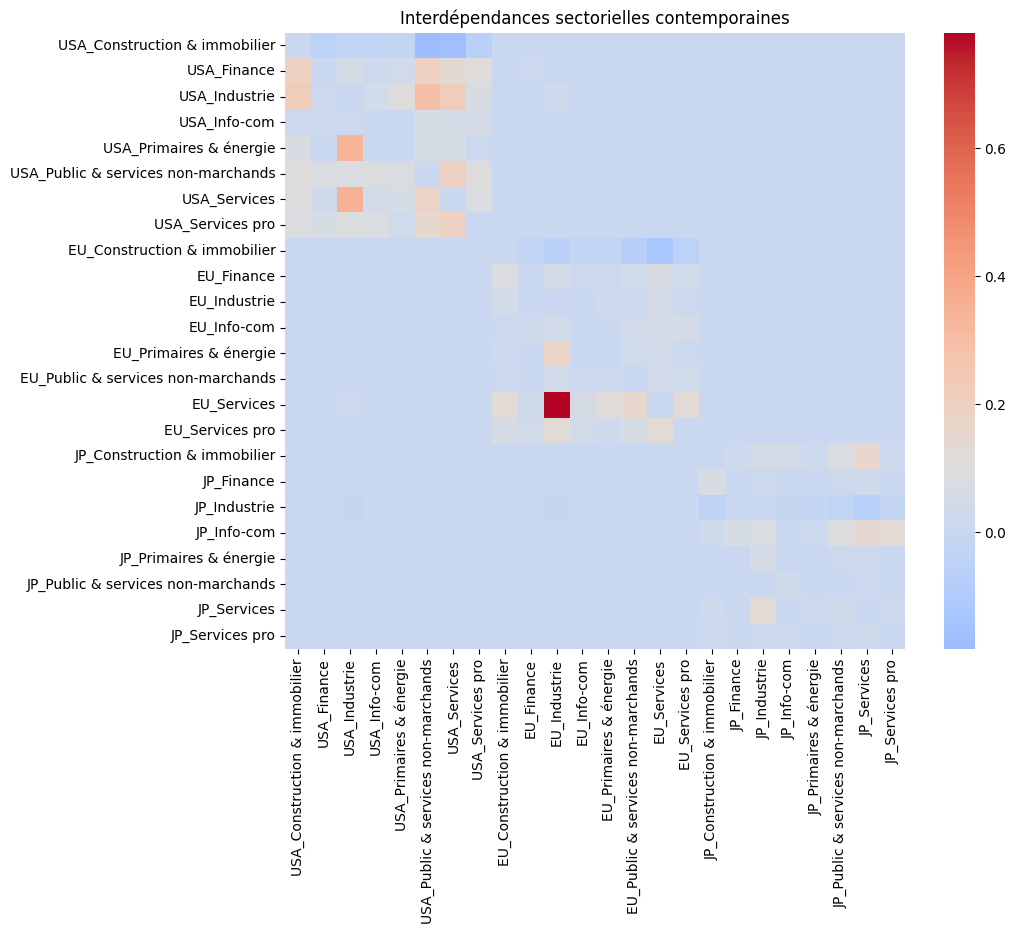

In [210]:
sector_effects = Lambda0 @ W_global
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(sector_effects, cmap="coolwarm", center=0.1)
plt.title("Interdépendances sectorielles contemporaines")
plt.show()

Matrice de propagation des effets du trimestre précédent

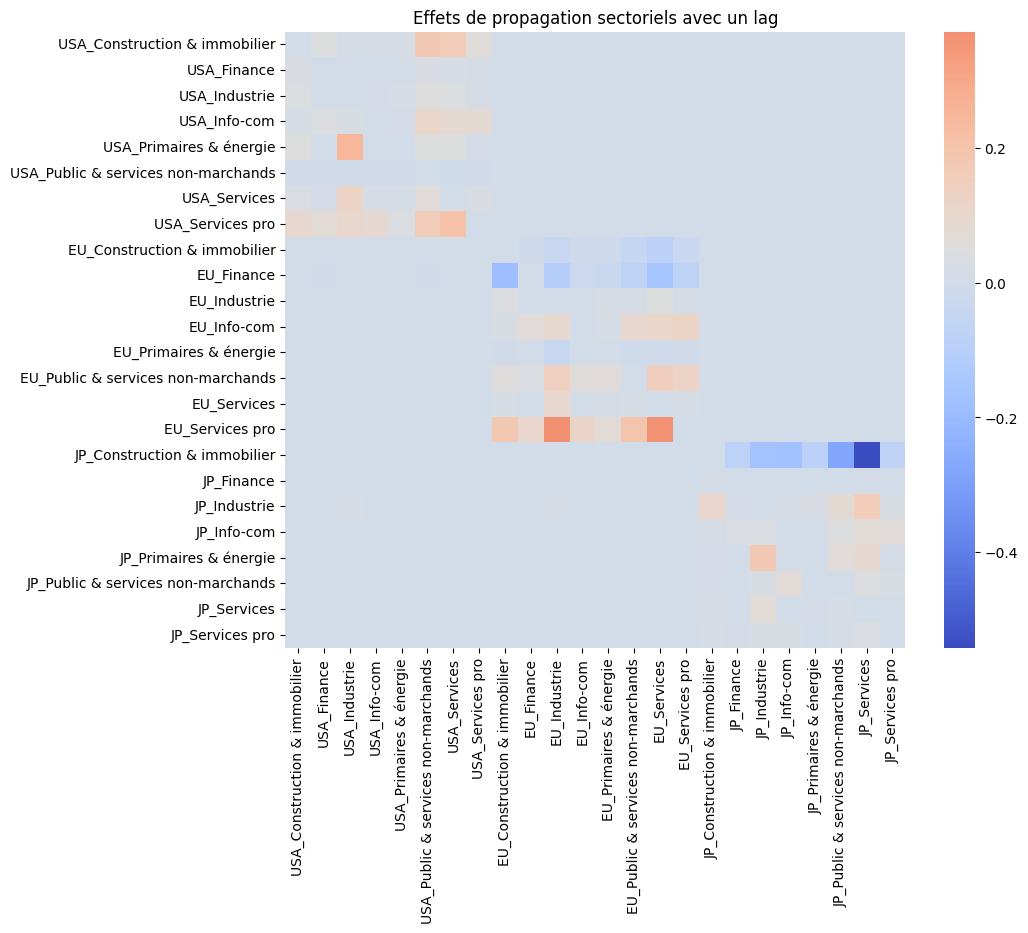

In [209]:
sector_lag_effects = Lambda1 @ W_global
plt.figure(figsize=(10,8))
sns.heatmap(sector_lag_effects, cmap="coolwarm", center=0.05)
plt.title("Effets de propagation sectoriels avec un lag")
plt.show()

Influence totale

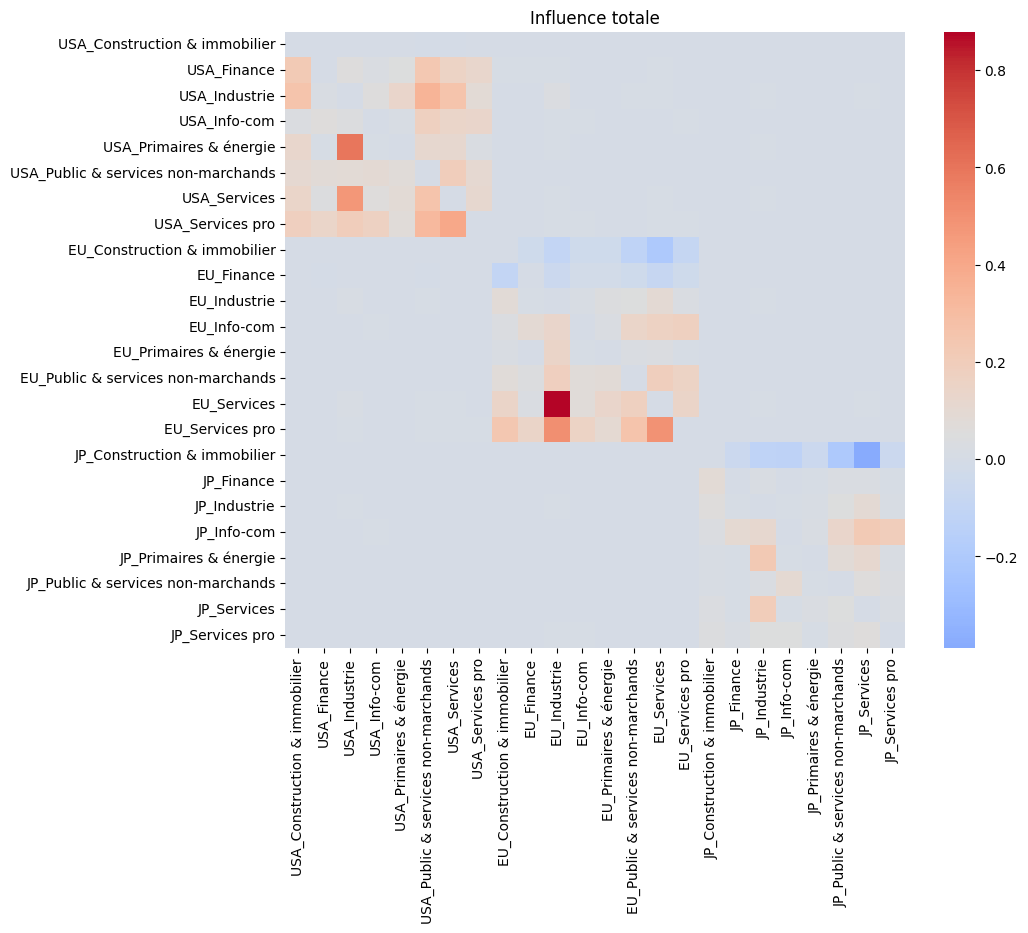

In [211]:
total_sector_effect = sector_effects + sector_lag_effects
plt.figure(figsize=(10,8))
sns.heatmap(total_sector_effect, cmap="coolwarm", center=0.05)
plt.title("Influence totale")
plt.show()

Les secteurs qui influencent le plus les autres

In [212]:
sector_influence = sector_effects.abs().sum(axis=0)
sector_influence.sort_values(ascending=False)

EU_Industrie                           1.354885
USA_Public & services non-marchands    1.163774
USA_Services                           1.051545
USA_Industrie                          0.997070
USA_Construction & immobilier          0.810436
EU_Services                            0.536766
USA_Services pro                       0.514172
JP_Services                            0.479779
EU_Public & services non-marchands     0.443470
EU_Construction & immobilier           0.386677
JP_Industrie                           0.385630
USA_Primaires & énergie                0.351233
EU_Services pro                        0.344979
USA_Info-com                           0.319886
JP_Public & services non-marchands     0.297474
USA_Finance                            0.278848
EU_Primaires & énergie                 0.239121
JP_Services pro                        0.200831
JP_Construction & immobilier           0.199263
EU_Info-com                            0.184261
EU_Finance                             0

Les secteurs les plus sensibles aux autres

In [213]:
sector_sensitivity = sector_effects.abs().sum(axis=1)
sector_sensitivity.sort_values(ascending=False)

EU_Services                            1.437794
USA_Industrie                          1.036790
USA_Services                           0.901355
USA_Finance                            0.794222
USA_Public & services non-marchands    0.768833
USA_Services pro                       0.736455
USA_Primaires & énergie                0.578700
JP_Info-com                            0.569419
USA_Construction & immobilier          0.516081
EU_Services pro                        0.512907
JP_Construction & immobilier           0.402390
EU_Construction & immobilier           0.371802
EU_Finance                             0.322103
EU_Primaires & énergie                 0.306720
EU_Info-com                            0.242847
USA_Info-com                           0.242763
JP_Services                            0.229155
JP_Industrie                           0.198379
EU_Industrie                           0.184046
EU_Public & services non-marchands     0.175793
JP_Finance                             0

Effet marginaux des variables macro via le système du GVAR

In [215]:
A0_inv = pd.DataFrame(
    np.linalg.inv(A0.values),
    index=A0.index,
    columns=A0.columns
)

B = A0_inv @ Gamma

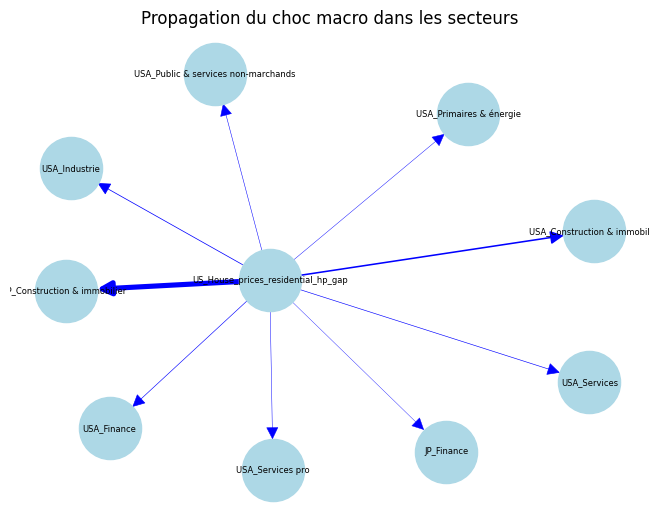

In [225]:
import networkx as nx
import matplotlib.pyplot as plt

macro = "US_House_prices_residential_hp_gap"

G = nx.DiGraph()

edges = []

for sector, val in B[macro].items():

    if abs(val) > 0.05:   # seuil

        G.add_edge(macro, sector, weight=abs(val), sign=np.sign(val))
        edges.append((macro, sector, val))

pos = nx.spring_layout(G, seed=42)

# largeur proportionnelle
weights = [abs(v) * 5 for _,_,v in edges]

# couleur selon le signe
colors = ["red" if v < 0 else "blue" for _,_,v in edges]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    width=weights,
    edge_color=colors,
    arrowsize=20,
    font_size=6
)

plt.title("Propagation du choc macro dans les secteurs")
plt.show()

In [239]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def plot_top_affected_sectors(
    sector_matrix: pd.DataFrame,
    source_sector: str,
    top_n: int = 8,
    figsize: tuple = (10, 7),
    seed: int = 1
):
    """
    Affiche un réseau orienté depuis un secteur source vers les top_n secteurs
    les plus affectés selon la matrice sectorielle.

    Parameters
    ----------
    sector_matrix : pd.DataFrame
        Matrice des effets sectoriels, typiquement Lambda0 @ W_global.
        Les lignes = secteurs cibles, les colonnes = secteurs sources.
    source_sector : str
        Nom du secteur source (doit être dans les colonnes de sector_matrix).
    top_n : int
        Nombre de secteurs cibles à afficher.
    figsize : tuple
        Taille de la figure.
    seed : int
        Seed pour le layout networkx.
    """

    if source_sector not in sector_matrix.columns:
        raise ValueError(f"{source_sector} n'existe pas dans les colonnes de sector_matrix.")

    # Effets du secteur source sur tous les secteurs cibles
    effects = sector_matrix[source_sector].copy()

    # On enlève l'auto-effet éventuel
    if source_sector in effects.index:
        effects = effects.drop(index=source_sector)

    # On garde les top_n effets en valeur absolue
    top_effects = effects.reindex(
        effects.abs().sort_values(ascending=False).head(top_n).index
    )

    # Création du graphe
    G = nx.DiGraph()
    G.add_node(source_sector)

    for target_sector, val in top_effects.items():
        G.add_edge(
            source_sector,
            target_sector,
            weight=abs(val),
            sign=np.sign(val),
            value=val
        )

    # Position : source au centre-gauche, cibles autour
    pos = nx.spring_layout(G, seed=seed)

    # Styles
    edges = list(G.edges(data=True))
    weights = [d["weight"] * 8 for (_, _, d) in edges]
    colors = ["red" if d["sign"] < 0 else "blue" for (_, _, d) in edges]

    # Taille des noeuds
    node_sizes = []
    for node in G.nodes():
        if node == source_sector:
            node_sizes.append(3200)
        else:
            node_sizes.append(2200)

    plt.figure(figsize=figsize)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=node_sizes,
        node_color=["gold" if node == source_sector else "lightblue" for node in G.nodes()],
        width=weights,
        edge_color=colors,
        arrowsize=20,
        font_size=10
    )

    # Ajouter les labels des coefficients sur les flèches
    edge_labels = {
        (u, v): f"{d['value']:.3f}"
        for u, v, d in edges
    }
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=9
    )

    plt.title(f"Top {top_n} secteurs les plus affectés par {source_sector}")
    plt.axis("off")
    plt.show()

    return top_effects

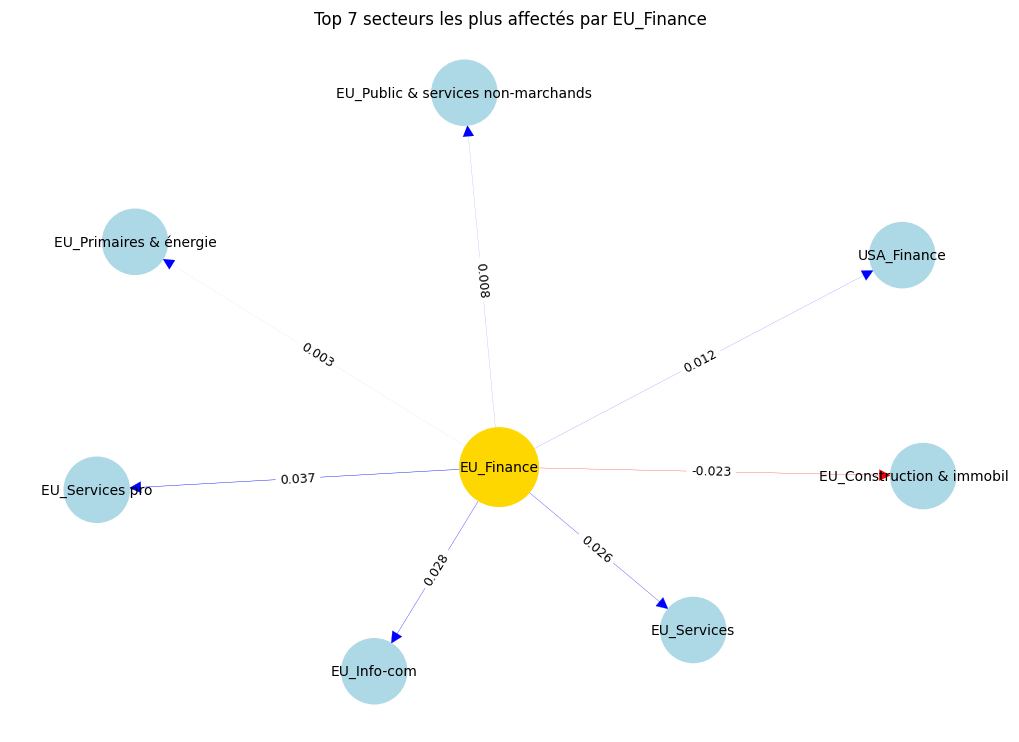

EU_Services pro                       0.037497
EU_Info-com                           0.028076
EU_Services                           0.025648
EU_Construction & immobilier         -0.023058
USA_Finance                           0.011646
EU_Public & services non-marchands    0.008450
EU_Primaires & énergie                0.002790
Name: EU_Finance, dtype: float64


In [242]:
sector_matrix = Lambda0 @ W_global

top_effects = plot_top_affected_sectors(
    sector_matrix=sector_matrix,
    source_sector="EU_Finance",
    top_n=7
)

print(top_effects)

In [229]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

In [230]:
def sankey_zone_to_zone(sector_matrix: pd.DataFrame):
    """
    Agrège les effets sectoriels en flux zone -> zone.
    """
    links = sector_matrix.stack().reset_index()
    links.columns = ["source_sector", "target_sector", "value"]

    links = links[links["value"] != 0].copy()

    links["source_zone"] = links["source_sector"].str.split("_").str[0]
    links["target_zone"] = links["target_sector"].str.split("_").str[0]
    links["abs_value"] = links["value"].abs()

    zone_links = (
        links.groupby(["source_zone", "target_zone"], as_index=False)["abs_value"]
        .sum()
    )

    labels = sorted(set(zone_links["source_zone"]).union(set(zone_links["target_zone"])))
    label_to_id = {label: i for i, label in enumerate(labels)}

    source = zone_links["source_zone"].map(label_to_id).tolist()
    target = zone_links["target_zone"].map(label_to_id).tolist()
    values = zone_links["abs_value"].tolist()

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=25,
            thickness=22,
            line=dict(color="black", width=0.5),
            label=labels
        ),
        link=dict(
            source=source,
            target=target,
            value=values
        )
    )])

    fig.update_layout(
        title_text="Sankey – flux d'interdépendance entre zones",
        font_size=12,
        height=600
    )
    fig.show()

In [231]:
sector_matrix = Lambda0 @ W_global
sankey_zone_to_zone(sector_matrix)

In [234]:
def sankey_macro_to_sectors(B: pd.DataFrame, macro: str, top_n: int = 12, use_abs=True):
    """
    Sankey d'une variable macro vers les secteurs.
    
    B : matrice des effets totaux (secteurs x macros)
    macro : nom de la variable macro
    top_n : nombre de secteurs les plus touchés à afficher
    use_abs : si True, on classe par effet absolu
    """
    effects = B[macro].copy()

    if use_abs:
        effects = effects.reindex(effects.abs().sort_values(ascending=False).head(top_n).index)
    else:
        effects = effects.sort_values(ascending=False).head(top_n)

    sectors = effects.index.tolist()

    labels = [macro] + sectors
    source = [0] * len(sectors)
    target = list(range(1, len(sectors) + 1))
    values = effects.abs().tolist()

    # couleur selon le signe
    link_colors = [
        "rgba(31,119,180,0.6)" if v >= 0 else "rgba(214,39,40,0.6)"
        for v in effects.values
    ]

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
            color=link_colors,
            customdata=np.round(effects.values, 4),
            hovertemplate="Source: %{source.label}<br>Cible: %{target.label}<br>Effet: %{customdata}<extra></extra>"
        )
    )])

    fig.update_layout(
        title_text=f"Sankey – propagation de {macro} vers les secteurs",
        font_size=11,
        height=700
    )
    fig.show()

In [235]:
sankey_macro_to_sectors(B, macro="US_House_prices_residential_hp_gap", top_n=10)

In [236]:
sankey_macro_to_sectors(B, macro="EU_GDP_Growth_Rate_lag1", top_n=10)

In [237]:
sankey_macro_to_sectors(B, macro="US_Unemployment_rate_hp_gap_lag1", top_n=10)

### Fonctions de reponses impulsionnelles

In [243]:
A0_inv = pd.DataFrame(
    np.linalg.inv(A0.values),
    index=A0.index,
    columns=A0.columns
)

Phi = A0_inv @ A1
B = A0_inv @ Gamma

In [ ]:
def irf_sector_shock(Phi: pd.DataFrame, shock_sector: str, horizon: int = 12, shock_size: float = 1.0):
    
    sectors = list(Phi.index)
    
    if shock_sector not in sectors:
        raise ValueError(f"{shock_sector} n'est pas dans Phi.index")
    
    N = len(sectors)
    e = np.zeros(N)
    e[sectors.index(shock_sector)] = shock_size
    
    responses = []
    
    for h in range(horizon + 1):
        Phi_h = np.linalg.matrix_power(Phi.values, h)
        resp_h = Phi_h @ e
        responses.append(resp_h)
    
    irf_df = pd.DataFrame(
        responses,
        columns=sectors,
        index=range(horizon + 1)
    )
    irf_df.index.name = "horizon"
    
    return irf_df

In [ ]:
def plot_irf_top_sectors(irf_df: pd.DataFrame, title: str, top_n: int = 8, criterion: str = "peak"):
    
    if criterion == "peak":
        scores = irf_df.abs().max(axis=0)
    elif criterion == "final":
        scores = irf_df.iloc[-1].abs()
    else:
        raise ValueError("criterion doit être 'peak' ou 'final'")
    
    top_sectors = scores.sort_values(ascending=False).head(top_n).index
    
    plt.figure(figsize=(10, 6))
    
    for sector in top_sectors:
        plt.plot(irf_df.index, irf_df[sector], label=sector)
    
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("Horizon")
    plt.ylabel("Réponse")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [1]:
irf_eu_finance = irf_sector_shock(Phi, shock_sector="EU_Finance", horizon=12, shock_size=1.0)
plot_irf_top_sectors(
    irf_eu_finance,
    title="IRF à un choc sectoriel sur EU_Finance",
    top_n=10
)

NameError: name 'irf_sector_shock' is not defined

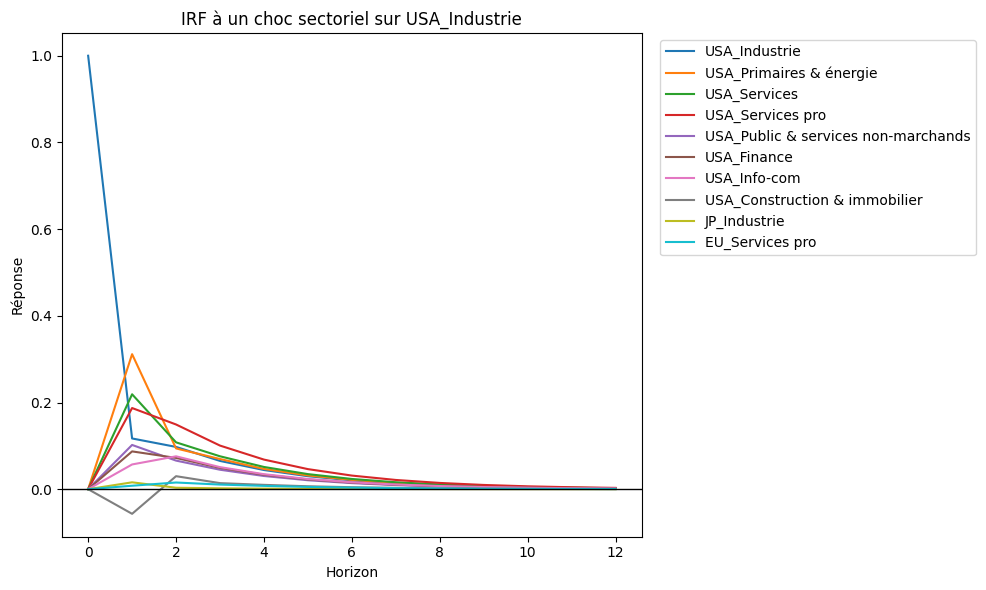

In [253]:
irf_usa_industrie = irf_sector_shock(Phi, shock_sector="USA_Industrie", horizon=12, shock_size=1.0)
plot_irf_top_sectors(
    irf_usa_industrie,
    title="IRF à un choc sectoriel sur USA_Industrie",
    top_n=10
)

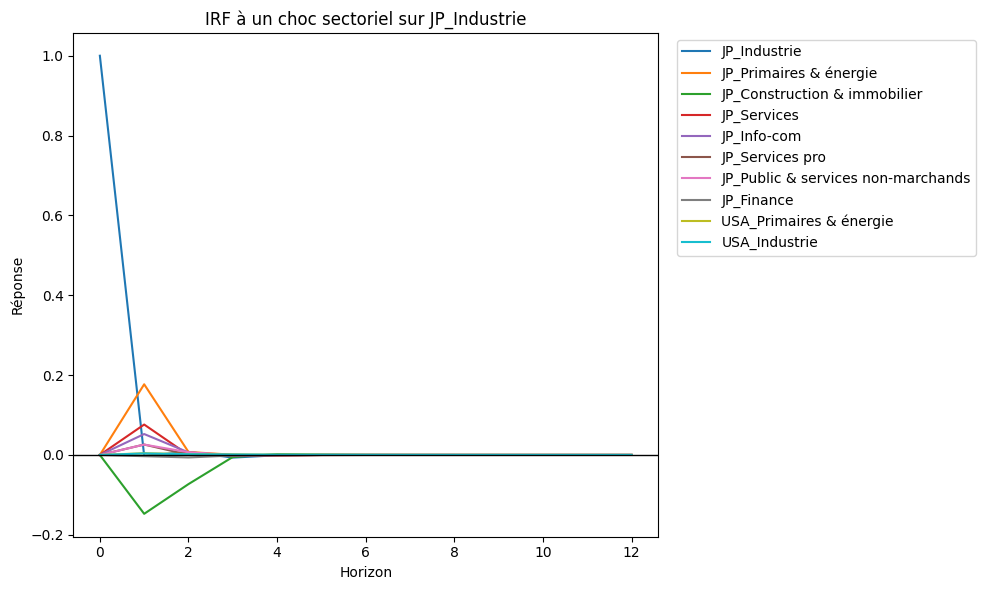

In [255]:
irf_jp_industrie = irf_sector_shock(Phi, shock_sector="JP_Industrie", horizon=12, shock_size=1.0)
plot_irf_top_sectors(
    irf_jp_industrie,
    title="IRF à un choc sectoriel sur JP_Industrie",
    top_n=10
)

### Effets marginaux des variables macro

In [256]:
def dynamic_marginal_effect(
    Phi: pd.DataFrame,
    B: pd.DataFrame,
    exog_var: str,
    horizon: int = 12,
    shock_size: float = 1.0
):
    if exog_var not in B.columns:
        raise ValueError(f"{exog_var} n'est pas dans B.columns")

    impact0 = shock_size * B[exog_var].values

    responses = []
    for h in range(horizon + 1):
        Phi_h = np.linalg.matrix_power(Phi.values, h)
        responses.append(Phi_h @ impact0)

    out = pd.DataFrame(
        responses,
        columns=Phi.index,
        index=range(horizon + 1)
    )
    out.index.name = "horizon"
    return out

In [257]:
dme_house = dynamic_marginal_effect(
    Phi=Phi,
    B=B,
    exog_var="US_House_prices_residential_hp_gap",
    horizon=12,
    shock_size=1.0
)

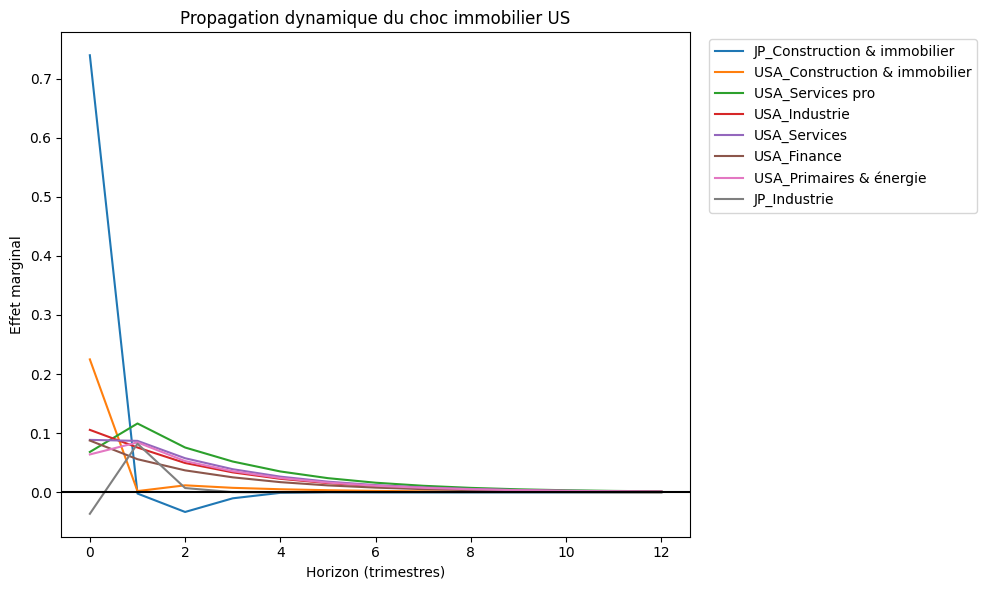

In [258]:
top_sectors = dme_house.abs().max().sort_values(ascending=False).head(8).index

plt.figure(figsize=(10,6))

for sector in top_sectors:
    plt.plot(dme_house.index, dme_house[sector], label=sector)

plt.axhline(0, color="black")

plt.xlabel("Horizon (trimestres)")
plt.ylabel("Effet marginal")

plt.title("Propagation dynamique du choc immobilier US")

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

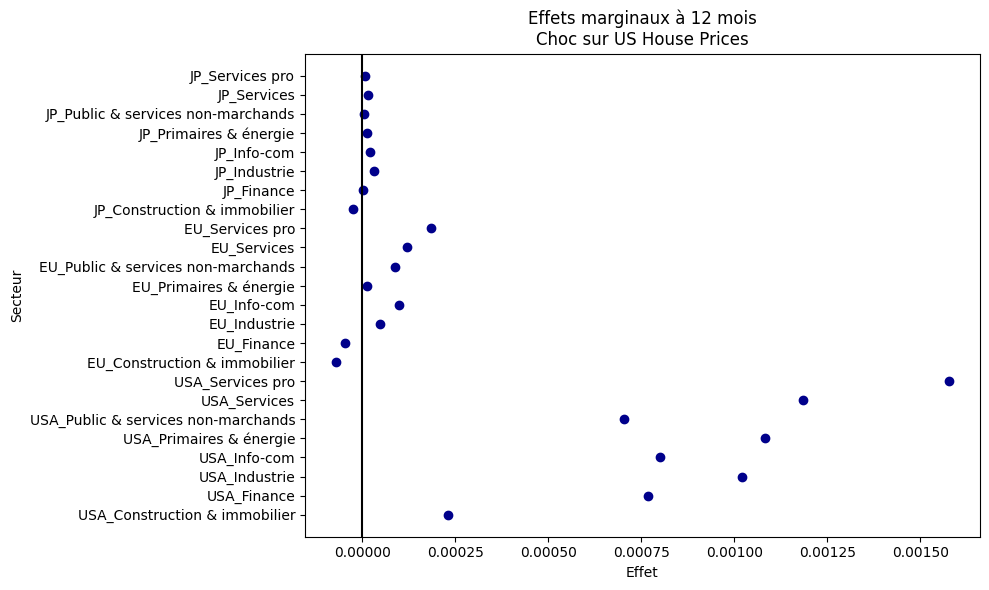

In [259]:
effects = dme_house.loc[12]

plt.figure(figsize=(10,6))

plt.scatter(
    effects.values,
    range(len(effects)),
    color="darkblue"
)

plt.yticks(range(len(effects)), effects.index)

plt.axvline(0, color="black")

plt.title("Effets marginaux à 12 mois\nChoc sur US House Prices")

plt.xlabel("Effet")
plt.ylabel("Secteur")

plt.tight_layout()
plt.show()